**Content Produced by UF Signal Processing Society**

**Authors: Awwab Azam**

# Intro to Deep Learning using PyTorch

This is the first of a planned 3-part series covering the basics of deep learning for applications in Physics and Engineering. In this workshop, we will learn how to use PyTorch to train a very simple neural network, as well as some hand-wavy ML theory. Let's get started!

### Setup

For this tutorial, we will need several Python packages, including PyTorch, NumPy, and MatplotLib. If you are not very tech-savvy, the easiest thing to do would be to open this notebook in Google Colab using the link at the top. Google Colab is an online cloud-based development environment that comes with all these packages preinstalled.

For those who are comfortable working with Python virtual environments and would like to run the code locally, please make sure you have all the packages in the import section installed.

## 0. Getting started

First we need to import the packages that we want to use.

In [1]:
# imports
import torch
import numpy as np

## 1. Tensors

The foundational building block in PyTorch is a tensor, which is basically a multidimensional array. You can make a tensor in several ways, as follows. Random tensors are often useful if you want dummy data to test your model.

In [2]:
# a tensor of zeroes
zero_tensor = torch.zeros(2, 2)
# a tensor of ones
ones_tensor = torch.ones(2, 2)
# a tensor of random numbers
randn_tensor = torch.randn(2, 2)

print(zero_tensor)
print(ones_tensor)
print(randn_tensor)

tensor([[0., 0.],
        [0., 0.]])
tensor([[1., 1.],
        [1., 1.]])
tensor([[-0.1691, -0.2942],
        [ 1.5494,  1.5369]])


You can also make a tensor from a NumPy array and vice versa. The PyTorch tensor and the NumPy array will share the same underlying memory, so be careful if you change anything!

In [3]:
np_arr = np.random.random((2, 2))
# should be random
print(np_arr)

tensor = torch.from_numpy(np_arr)
tensor[0, 0] = 0
# should have a zero in the top left corner
print(np_arr)

# notice that we never directly modified np_arr!

[[0.47538306 0.17266585]
 [0.09512851 0.4352773 ]]
[[0.         0.17266585]
 [0.09512851 0.4352773 ]]


### Indexing and slicing

If you're familiar with NumPy, PyTorch indexing/slicing is quite similar. If not, no problem, we'll go through it step-by-step.

First things first: Python is 0-indexed, which means that the first element of any dimension in a tensor (or array, or list, etc) IS 0, NOT 1. You can ask a specific element by using the syntax `T[i]` where T is an arbitrary 1D tensor and i is the (0-based) index. If you have more dimensions, you can simply use more indices, i.e. `T[x, y, z]` for a 3D tensor.

Also, keep in mind that (just like in linear algebra), Python is row-major, so e.g. for 2D arrays, the first index determines the **row** and the second index determined the **column**.

You can use a colon : to select all elements in a certain dimension, and an ellipsis ... to select all elements from an unspecified number of dimensions.

In [4]:
# make a random 3D tensor (5x4x4)
T = torch.randn(5, 4, 4)
print(T)

# get a specific element
print(T[0, 1, 3])

# get the 1st 4x4 matrix
f = T[0, :, :]
print(f)

# alternatively, you can use an ellipsis
print(T[0, ...] == f)

tensor([[[ 0.0607,  1.3529, -0.9630, -0.3736],
         [ 1.1492, -0.4702, -0.6720,  0.0117],
         [-0.1069,  1.3170,  0.2722, -0.6709],
         [-0.2238, -0.9536,  0.0569, -1.1026]],

        [[-0.5868, -1.0386,  0.2336, -0.2003],
         [ 0.5963,  0.3297,  0.6209, -0.5949],
         [ 0.2405,  0.3419, -0.2242,  0.9210],
         [ 0.2696,  0.4122,  0.1170,  0.4488]],

        [[ 0.1990,  0.1593, -1.1975, -0.7083],
         [-1.7462, -0.6654,  0.8864, -1.5048],
         [ 0.2311, -1.5651,  1.2618, -0.2505],
         [-0.9040,  0.1978,  0.3541,  1.0732]],

        [[ 0.1621, -0.5366,  0.8676,  1.2807],
         [-0.2708, -0.5726, -0.8344,  0.0618],
         [-1.3503, -0.3582,  0.2320, -0.4685],
         [-0.7539,  0.0189, -0.2728, -0.8928]],

        [[ 0.2794,  1.6040, -0.3271,  0.2196],
         [-2.0210, -1.7773,  0.1974, -0.1551],
         [ 0.3083, -0.1931,  0.5335, -0.3379],
         [ 1.0707, -0.1807,  0.2535, -2.1934]]])
tensor(0.0117)
tensor([[ 0.0607,  1.3529, -0.9630,

## 2. Datasets & Dataloaders

The basic premise of machine learning is to define a function as an ansatz with some number of free parameters, and then optimize those parameters based on the training data. Thus, data is a fundamental part of the process to train any neural network. In PyTorch, we can use the Dataset class as a flexible container for our data.

For this example (since this is supposed to be machine learning for physics applications, after all) we take the sample task of computing the 2D (discrete) Fourier transform of a 16x16 matrix. Thankfully, PyTorch already has a built-in Fast Fourier Transform (FFT) function, so We can generate our data easily. For simplicity, we start with 1000 input/output samples.

In [6]:
# make the input tensor - 10K samples of 16x16 matrices
input_matrices = torch.randn(1000, 16, 16)
output_matrices = torch.fft.fft2(input_matrices)

Let's check the data types of our inputs and outputs. In PyTorch, you can do this using the .dtype property. The data type is generally either an `int` (integer), `float` (decimal), `complex` (complex decimal), or `bool` (Boolean value i.e. True/False), followed by the number of bits used to represent the number (for numeric dtypes) in memory. More bits obviously mean a higher range/precision, but also more memory usage. The most common dtype you will use will probably be `float32` (i.e., a decimal number stored in 32 bits, or 4 bytes of memory).

In [7]:
print(f"Input Data Type: {input_matrices.dtype}")
print(f"Output Data Type: {output_matrices.dtype}")

Input Data Type: torch.float32
Output Data Type: torch.complex64


Oh wait! Our outputs are complex numbers! If you don't remember the formula for the FFT (I don't), here it is:

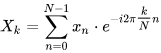

As you can see, there is a factor of $i$, the imaginary unit, so it makes sense that `output_matrices` has a complex data type.